In [1]:
import networkx as nx 
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
#import EoN
from tqdm import trange
import seaborn as sns
import pandas as pd
import random

In [2]:
dire = "../long_sw_100000_fin/"
sw = pd.read_csv('test_files.csv').iloc[::10].values

dire_ba = "../new_ba_100000/"
ba = pd.read_csv('ba_test_files.csv').iloc[::10].values

In [3]:
import glob
sw_files = glob.glob(dire+'p*.csv')
ba_files = glob.glob(dire_ba+'p*.csv')
len(ba_files),len(sw_files)

(72000, 72000)

0 1471


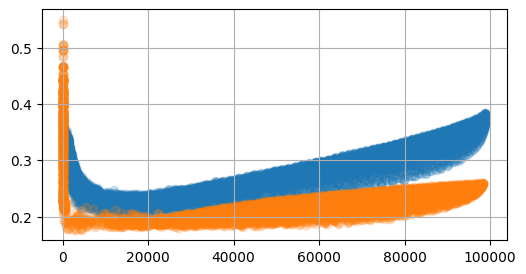

In [4]:
fig, axes = plt.subplots(1,1, figsize=(6,3),squeeze=False)
ax = axes.flatten()

ba_df = []
sw_df = []
ba_0 = 0
sw_0 = 0
for i,file in enumerate(ba_files[::10]):
    _, beta, gc,dc, initi, alpha, _, seed = file.split('\\')[-1].split('_')
    df = pd.read_csv(dire_ba+file, usecols=['S','E'])
    temp = df[['E','S']].shift([0,1])
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                        (temp['S_0'] - temp['S_1'])
    df['incidence'] = df['incidence'].fillna(0)
    
    #v_{ij} = (- sum_i (p_{ij}*log(p_{ij}))  )^{-1}
    # p_{ij} == K/N == sick on i / total sick on all i
    total_inc = df.incidence.sum()
    if total_inc == 0:
        ba_0+=1
    else:    
        p_ij = df.incidence / total_inc
        log_pij = np.log(p_ij+1e-10)
        v_ij = (-np.sum(p_ij*log_pij))**(-1)
        
        ba_df.append([total_inc, v_ij, alpha, beta, 'ba'])
        ax[0].scatter(total_inc, v_ij, color='tab:blue', alpha=.2)

        
for i,file in enumerate(sw_files[::10]):
    _, beta, gc,dc, initi, alpha, _, seed = file.split('\\')[-1].split('_')
    df = pd.read_csv(dire+file, usecols=['S','E'])
    temp = df[['E','S']].shift([0,1])
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                        (temp['S_0'] - temp['S_1'])
    df['incidence'] = df['incidence'].fillna(0)
    
    #v_{ij} = (- sum_i (p_{ij}*log(p_{ij}))  )^{-1}
    # p_{ij} == K/N == sick on i / total sick on all i
    total_inc = df.incidence.sum()
    if total_inc <= 10:
        sw_0 += 1
    else:
        p_ij = df.incidence / total_inc
        log_pij = np.log(p_ij+1e-10)
        v_ij = (-np.sum(p_ij*log_pij))**(-1)
        sw_df.append([total_inc, v_ij, alpha, beta, 'sw'])
        ax[0].scatter(total_inc, v_ij, color='tab:orange', alpha=.2)

ba_df = pd.DataFrame(ba_df, columns=['total_inc','v','alpha','beta','name'])  
sw_df = pd.DataFrame(sw_df, columns=['total_inc','v','alpha','beta','name']) 
print(ba_0, sw_0)
ax[0].grid() 

In [5]:
all_df = pd.concat([ba_df, sw_df])
all_df.v.min(), all_df.v.max()

(np.float64(0.1764805568910674), np.float64(0.5494276139689521))

In [6]:
all_df['v_norm'] = (all_df.v - all_df.v.min())/all_df.v.max()

<Axes: xlabel='total_inc', ylabel='v_norm'>

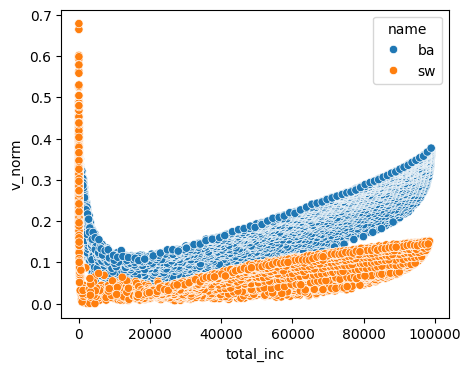

In [9]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=all_df['total_inc'], y=all_df['v_norm'], 
                hue=all_df['name'])

<Axes: xlabel='total_inc', ylabel='v_norm'>

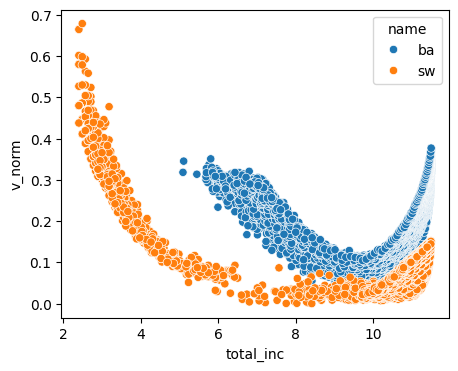

In [10]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=np.log(all_df['total_inc']), y=all_df['v_norm'], 
                hue=all_df['name'])

In [ ]:
1

In [12]:
all_df['alpha'].astype(float)*all_df['beta'].astype(float)

0       0.0231
1       0.0242
2       0.0253
3       0.0264
4       0.0275
         ...  
5724    0.8640
5725    0.8730
5726    0.8820
5727    0.8910
5728    0.8100
Length: 12929, dtype: float64

<Axes: xlabel='None', ylabel='v_norm'>

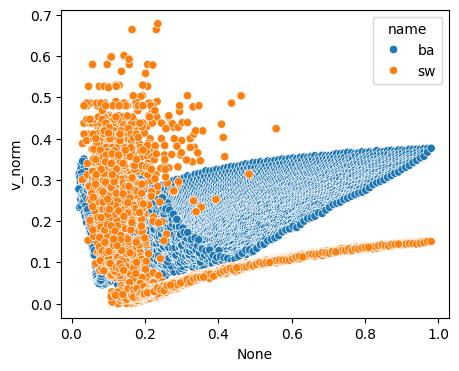

In [13]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=(all_df['alpha'].astype(float)*all_df['beta'].astype(float)
                  ), y=all_df['v_norm'], 
                hue=all_df['name'])

<Axes: xlabel='None', ylabel='total_inc'>

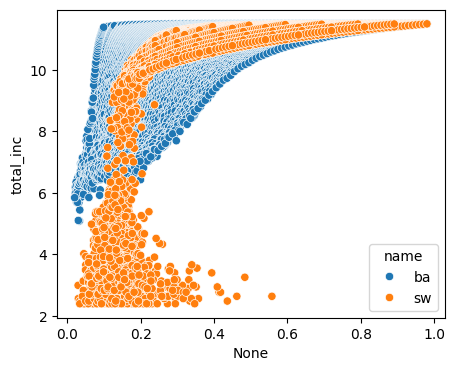

In [15]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=(all_df['alpha'].astype(float)*all_df['beta'].astype(float)
                  ), y=np.log(all_df['total_inc']), 
                hue=all_df['name'])

<Axes: xlabel='None', ylabel='total_inc'>

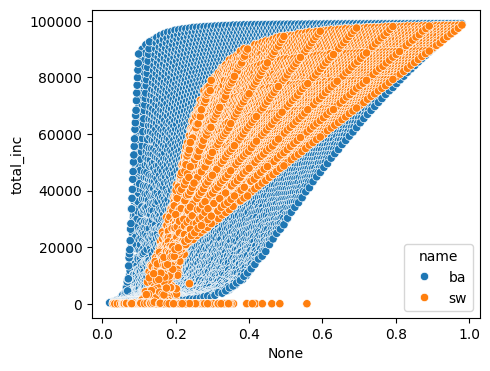

In [16]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=(all_df['alpha'].astype(float)*all_df['beta'].astype(float)
                  ), y=all_df['total_inc'], 
                hue=all_df['name'])

<Axes: xlabel='total_inc', ylabel='v'>

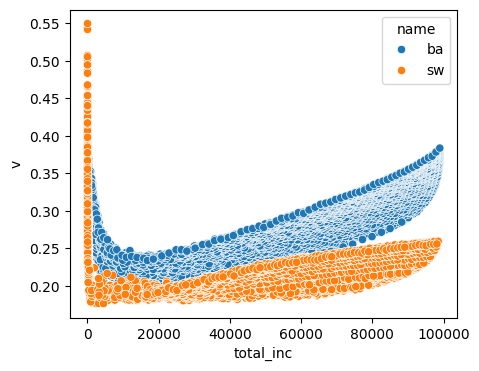

In [14]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=all_df['total_inc'], y=all_df['v'], 
                hue=all_df['name'])